# 04 - Portfolio waterfall - Task 14.5

Apply the PARTIAL split (`spec.md` §8, §9 step 3) to a batch of swaps and aggregate the Insurance Fund P&L.

Per swap:

- `payout       = min(realised_IL, MaxIL)`    (FULL cap, invariants I1+I2)
- `mm_pays      = min(payout, c·V0)`           (MM posts c of V0)
- `fund_pays    = max(0, payout - c·V0)`      (PARTIAL reinsurance tail)
- `fund_inflow  = premium · (share_to_fund + fee(c))`
- `fund_pnl     = fund_inflow - fund_pays`

This notebook is the simulator that Task 14.6 (correlated stress) and Task 14.7 (parameter calibration) ride on. All logic lives in `inflexion_quant.portfolio`; 23 property tests guard the invariants.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inflexion_quant.portfolio import WaterfallConfig, aggregate, default_fee_curve, waterfall
from inflexion_quant.positions import PositionMix, sample_positions
from inflexion_quant.prices import KouParams, gbm_paths, kou_jump_paths

rng = np.random.default_rng(seed=20260527)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3})

## A. Fee curve shape (placeholder; Task 14.7 calibrates)

The default convex curve `fee(c) = 1% · (0.20/c)^2.32` anchors at spec §8.3's `c=20% -> 1%` and `c=10% -> 5%`. It overshoots at very low `c` - that's the calibration job for 14.7.

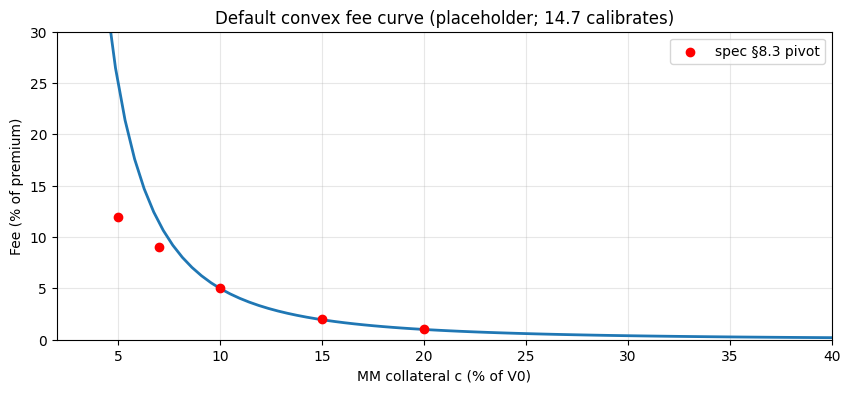

In [2]:
cs = np.linspace(0.03, 0.40, 80)
fees = np.array([default_fee_curve(c) for c in cs])
fig, ax = plt.subplots()
ax.plot(cs * 100, fees * 100, lw=2)
ax.set_xlabel('MM collateral c (% of V0)')
ax.set_ylabel('Fee (% of premium)')
ax.set_title('Default convex fee curve (placeholder; 14.7 calibrates)')
for c_pct, fee_pct in [(20, 1), (15, 2), (10, 5), (7, 9), (5, 12)]:
    ax.scatter([c_pct], [fee_pct], color='red', zorder=3, label='spec §8.3 pivot' if c_pct == 20 else None)
ax.legend(); ax.set_xlim(2, 40); ax.set_ylim(0, 30)
plt.show()

## B. Sample a 500-position book

Mix from notebook 02: 30% tight ±5%, 40% moderate ±15%, 25% wide ±30%, 5% v2-like ±80%. P0 = 100.

In [3]:
positions = sample_positions(500, P0=100.0, mix=PositionMix.crypto_majors(), rng=rng)
positions.head(8)

,bucket,half_width,offset_fraction,P0,Pa,Pb,L,V0
0,0,0.057830,-0.280527,100.0,93.053973,104.127750,30718.683680,17010.826209
1,1,0.182116,-0.020519,100.0,84.304117,117.806521,9151.592515,14688.032241
2,1,0.165742,-0.161505,100.0,83.683738,113.722325,40288.687119,59419.084273
3,1,0.141226,-0.082835,100.0,86.671421,112.880609,727.943488,930.362034
4,1,0.138940,-0.110680,100.0,86.545715,112.265780,10065.418877,12673.216300
5,1,0.146557,0.125286,100.0,88.724946,116.637220,849.374389,1122.226050
6,2,0.326593,0.010743,100.0,75.610311,133.062647,301.829309,795.478010
7,0,0.048468,-0.192535,100.0,94.512046,103.895717,2446.179415,1143.693295


## C. Two terminal-price scenarios

- **Calm:** 30-day GBM, sigma=20% annual.
- **Crash:** 30-day Kou jump-diffusion biased downward (one large down-jump on average over the horizon).

In [4]:
n = len(positions)
P0 = positions['P0'].to_numpy()
T_years = 30 / 365   # 30-day horizon
n_steps = 30

# Calm: GBM with 20% annual vol
calm_paths = gbm_paths(S0=P0[0], mu=0.0, sigma=0.20, T=T_years, n_steps=n_steps, n_paths=n, rng=rng)
P_T_calm = calm_paths[:, -1]

# Crash: Kou jump-diffusion biased downward
kou = KouParams(lam=10.0, p_up=0.35, eta_up=20.0, eta_down=15.0)
crash_paths = kou_jump_paths(S0=P0[0], mu=-0.05, sigma=0.30, T=T_years, n_steps=n_steps, n_paths=n, kou=kou, rng=rng)
P_T_crash = crash_paths[:, -1]

print(f'Calm:  P_T mean={P_T_calm.mean():.2f}  std={P_T_calm.std():.2f}  min={P_T_calm.min():.2f}  max={P_T_calm.max():.2f}')
print(f'Crash: P_T mean={P_T_crash.mean():.2f}  std={P_T_crash.std():.2f}  min={P_T_crash.min():.2f}  max={P_T_crash.max():.2f}')

Calm:  P_T mean=99.98  std=5.56  min=81.30  max=118.31
Crash: P_T mean=97.63  std=11.96  min=50.26  max=142.18


## D. Run the waterfall

Settings: `c=10%` collateral, `premium = 75% · MaxIL`, fund takes 20% of premium + the convex fee tax.

In [5]:
cfg = WaterfallConfig(c=0.10, premium_rate_of_maxil=0.75, premium_share_to_fund=0.20)

calm = waterfall(positions, P_T_calm, cfg)
crash = waterfall(positions, P_T_crash, cfg)

print('=== Aggregate (CALM) ===')
for k, v in aggregate(calm).items():
    print(f'  {k:>22}: {v:>14,.2f}')
print('\n=== Aggregate (CRASH) ===')
for k, v in aggregate(crash).items():
    print(f'  {k:>22}: {v:>14,.2f}')

=== Aggregate (CALM) ===
                 n_swaps:         500.00
         lp_payout_total:      44,660.97
           mm_pays_total:      44,660.97
         fund_pays_total:           0.00
       fund_inflow_total:      70,333.32
          fund_pnl_total:      70,333.32
        n_fund_tail_hits:           0.00
    max_single_fund_pays:           0.00

=== Aggregate (CRASH) ===
                 n_swaps:         500.00
         lp_payout_total:     105,468.99
           mm_pays_total:     103,989.82
         fund_pays_total:       1,479.18
       fund_inflow_total:      70,333.32
          fund_pnl_total:      68,854.15
        n_fund_tail_hits:           1.00
    max_single_fund_pays:       1,479.18


In [6]:
crash.sort_values('fund_pays', ascending=False).head(10)[[
    'V0', 'max_il', 'P_T', 'payout', 'mm_collateral', 'mm_pays', 'fund_pays', 'fund_inflow', 'fund_pnl'
]]

,V0,max_il,P_T,payout,mm_collateral,mm_pays,fund_pays,fund_inflow,fund_pnl
391,55535.289012,10582.518977,142.183501,7032.704698,5553.528901,5553.528901,1479.175797,1983.692298,504.516501
19,878.242945,180.911303,88.607025,6.284500,87.824294,6.284500,0.000000,33.911809,33.911809
484,24680.487010,1496.979954,83.667890,848.762827,2468.048701,848.762827,0.000000,280.608767,280.608767
483,3548.692717,439.859070,114.397822,60.454877,354.869272,60.454877,0.000000,82.451546,82.451546
2,59419.084273,2925.384744,101.741034,30.267844,5941.908427,30.267844,0.000000,548.363126,548.363126
469,22906.484564,330.967977,96.601910,141.122448,2290.648456,141.122448,0.000000,62.039920,62.039920
470,7130.128592,130.775684,100.701825,1.878353,713.012859,1.878353,0.000000,24.513891,24.513891
471,1033.376299,80.762072,115.204004,31.966385,103.337630,31.966385,0.000000,15.138844,15.138844
472,21050.238317,761.783122,102.738193,44.501820,2105.023832,44.501820,0.000000,142.796183,142.796183
473,7324.883215,491.281326,96.139677,13.906385,732.488322,13.906385,0.000000,92.090644,92.090644


## E. Fund P&L distribution per swap

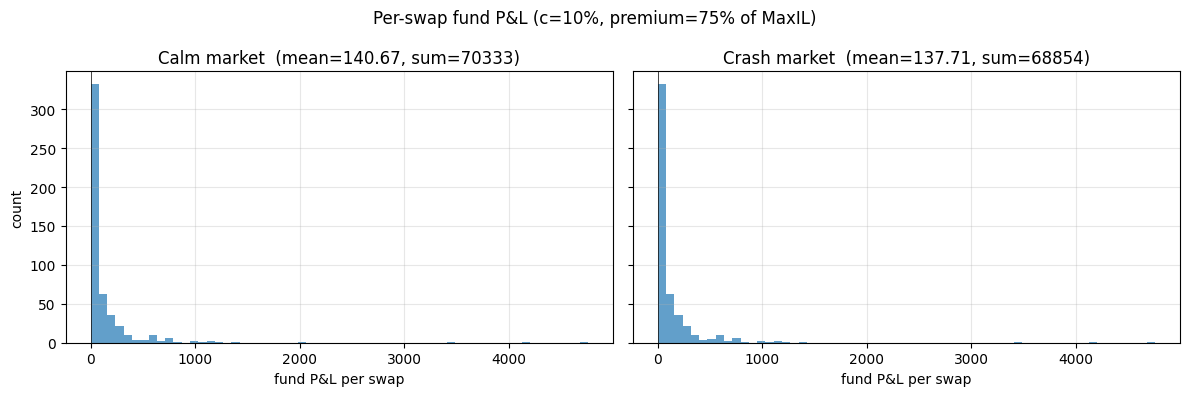

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, title in [(axes[0], calm['fund_pnl'], 'Calm market'), (axes[1], crash['fund_pnl'], 'Crash market')]:
    ax.hist(data, bins=60, alpha=0.7)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{title}  (mean={data.mean():.2f}, sum={data.sum():.0f})')
    ax.set_xlabel('fund P&L per swap')
axes[0].set_ylabel('count')
plt.suptitle('Per-swap fund P&L (c=10%, premium=75% of MaxIL)')
plt.tight_layout(); plt.show()

## F. Sweep over c - the calibration preview

How does the fund's aggregate P&L move as the PARTIAL collateral ratio shrinks? Lower `c` means MMs put up less, the fund covers a fatter tail, BUT the fee curve also charges them more, swelling fund inflow. Where these curves cross determines the safe `c_min` - the punchline of Task 14.7.

In [8]:
c_grid = np.array([0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 0.50])
rows = []
for c in c_grid:
    cfg_c = WaterfallConfig(c=float(c), premium_rate_of_maxil=0.75)
    for label, P_T in [('calm', P_T_calm), ('crash', P_T_crash)]:
        agg = aggregate(waterfall(positions, P_T, cfg_c))
        rows.append({'c': c, 'scenario': label, **agg})
sweep = pd.DataFrame(rows)
sweep[['c', 'scenario', 'fund_inflow_total', 'fund_pays_total', 'fund_pnl_total', 'n_fund_tail_hits']]

,c,scenario,fund_inflow_total,fund_pays_total,fund_pnl_total,n_fund_tail_hits
0,0.050,calm,126446.013834,0.000000,126446.013834,0
1,0.050,crash,126446.013834,5639.396960,120806.616873,18
2,0.075,calm,83671.224068,0.000000,83671.224068,0
3,0.075,crash,83671.224068,3089.353495,80581.870573,5
4,0.100,calm,70333.323322,0.000000,70333.323322,0
5,0.100,crash,70333.323322,1479.175797,68854.147524,1
6,0.150,calm,61766.924421,0.000000,61766.924421,0
7,0.150,crash,61766.924421,0.000000,61766.924421,0
8,0.200,calm,59095.776792,0.000000,59095.776792,0
9,0.200,crash,59095.776792,0.000000,59095.776792,0


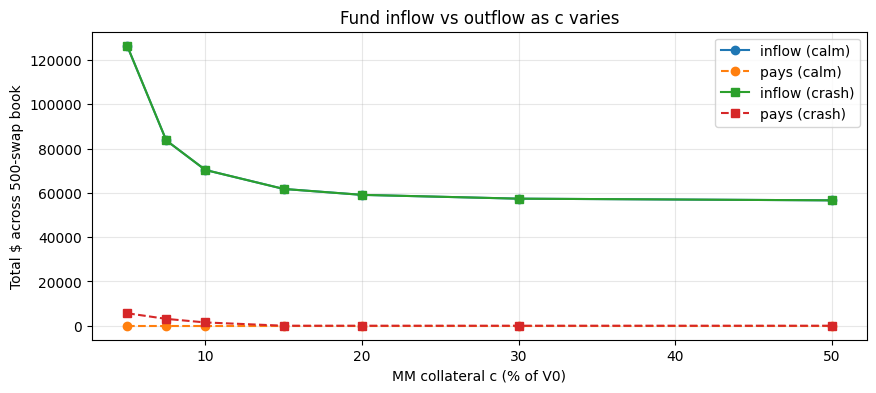

In [9]:
fig, ax = plt.subplots()
for scen, marker in [('calm', 'o'), ('crash', 's')]:
    sub = sweep[sweep['scenario'] == scen]
    ax.plot(sub['c'] * 100, sub['fund_inflow_total'], marker=marker, label=f'inflow ({scen})')
    ax.plot(sub['c'] * 100, sub['fund_pays_total'], marker=marker, linestyle='--', label=f'pays ({scen})')
ax.set_xlabel('MM collateral c (% of V0)')
ax.set_ylabel('Total $ across 500-swap book')
ax.set_title('Fund inflow vs outflow as c varies')
ax.legend(); plt.show()

## G. Next

**Task 14.6 - Stress scenarios.** Replace the per-position independent Kou paths with a *correlated* common-factor crash (`prices.common_factor_paths`): one shared market factor with a 6σ downward jump that drags the whole book at once. That is when the fund actually pays - per-swap stress is too soft because most positions are tight-range and barely move. The fund's P&L distribution under the 99.9th-percentile correlated crash is the input to Task 14.7's `c_min` and `floor_curve` calibration.